In [182]:
# Reading in the data and packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score

districts = pd.read_csv('district_level_expanded.csv')
districts['Council District'] = districts['Council District'].astype('category')
districts['ppl_per_house'] = districts['population']/districts['housing_units']
y = districts['report_rate_per_1000']
X = pd.get_dummies(districts[['ppl_per_house', 'pct_renter_occupied_among_occupied_units', 'restaurant_count', 'unemployment_rate']],drop_first=False)
district_numbers = districts['Council District']

In [186]:
# Creating test and training sets
X_train, X_test, y_train, y_test, dist_train, dist_test = train_test_split(X, y, district_numbers, test_size=0.25, random_state = 307)

In [187]:
# Creating random forest model and making predictions
FOREST = RandomForestRegressor(n_estimators=500, random_state = 307, oob_score=True, n_jobs=-1, max_depth = 10)
FOREST.fit(X_train,y_train)

y_pred = FOREST.predict(X_test)

In [188]:
# RMSE from a LOO CV
from sklearn.model_selection import LeaveOneOut, cross_val_score

loo = LeaveOneOut()
scores = cross_val_score(FOREST, X, y, cv=loo, scoring='neg_mean_squared_error')
rmse = (np.sqrt(-scores.mean()))
print("RMSE:", rmse)

RMSE: 1.425812649603617


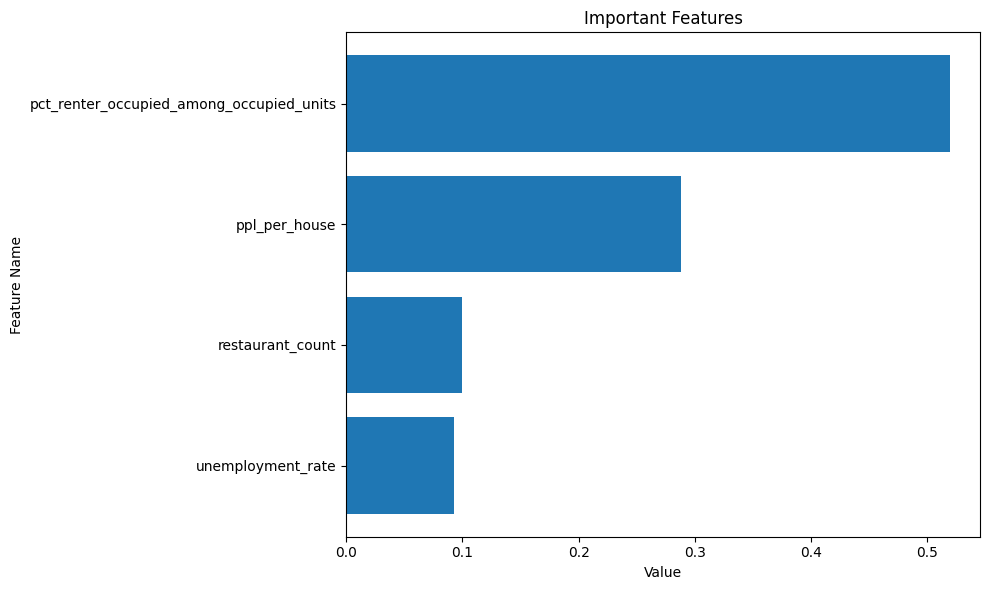

In [189]:
feat_imp = FOREST.feature_importances_

feature_names = X_train.columns
sorted_idx = np.argsort(feat_imp)[::-1]

sorted_feat_imp = feat_imp[sorted_idx][0:10]
sorted_features = feature_names[sorted_idx][0:10]

plt.figure(figsize=(10,6))
plt.barh(sorted_features, sorted_feat_imp)

plt.xlabel("Value")
plt.ylabel("Feature Name")
plt.title("Important Features")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [190]:
import shap
explainer = shap.TreeExplainer(FOREST)
shap_values = explainer(X_test)

human_exp = shap.Explanation(
    values=shap_values.values,
    base_values=shap_values.base_values,
    data=X_test,
    feature_names=feature_names,
)

print("SHAP value tensor shape:", shap_values.values.shape)
print("Explanation matrix shape for the Human class:", human_exp.values.shape)

SHAP value tensor shape: (13, 4)
Explanation matrix shape for the Human class: (13, 4)


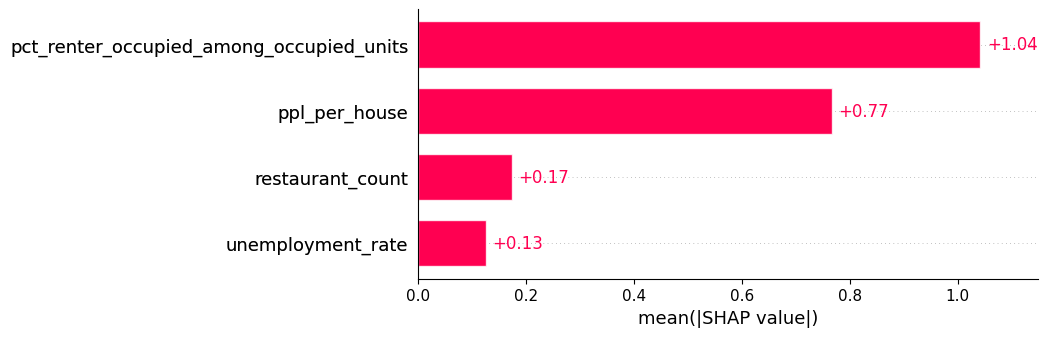

In [191]:
shap.plots.bar(human_exp)

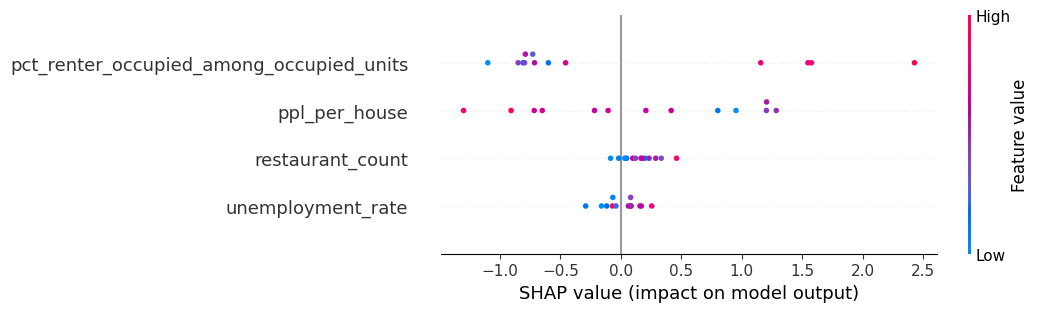

In [192]:
shap.plots.beeswarm(human_exp)